sindata : [ 0.00194863  0.21079218  0.57366226  0.6343844   0.68420567  0.89010742
  1.06098721  0.80942305  0.73523318  0.87692963  0.43920966  0.33840186
 -0.02007198 -0.31091541 -0.43023637 -0.5536844  -0.97613952 -0.79569057
 -0.88752442 -1.01526602 -0.85704668 -0.76757312 -0.49440139 -0.29652629
 -0.11014431  0.25698544  0.39087702  0.42207975  0.71784928  0.97027175
  0.97391057  1.04019961  0.99037744  1.06758272  0.60101673  0.47515796
  0.19463918 -0.03741798 -0.24354291 -0.5201825  -0.5833151  -0.93000141
 -1.13267616 -1.13740646 -1.09074356 -0.82689928 -0.82795732 -0.40111109
 -0.10012841  0.13789753]


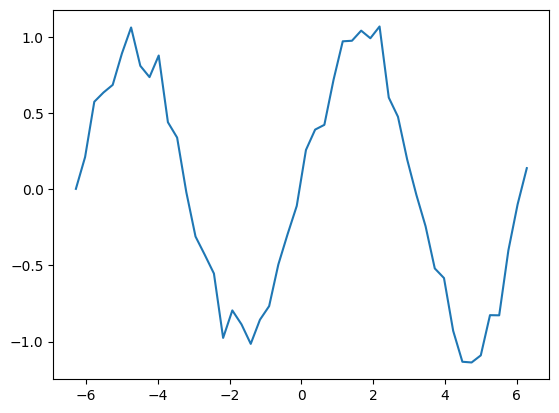

In [1]:
import numpy as np
import matplotlib.pyplot as plt
xdata = np.linspace(-2 * np.pi, 2 * np.pi)
sindata = np.sin(xdata) + 0.1 * np.random.randn(len(xdata))
print('sindata :', sindata)

plt.plot(xdata, sindata)
plt.show()

In [2]:
n_rnn = 10
n_sample = len(xdata) - n_rnn   # 학습 샘플 갯수
x = np.zeros((n_sample, n_rnn)) # 입력 시퀀스를 저장할 배열
t = np.zeros((n_sample, n_rnn)) # 예측 대상 시퀀스를 저장할 배열 (한 칸 뒤로 밀린 값을 정답 t로 생성)
for i in range(0, n_sample):
    x[i] = sindata[i:i + n_rnn]
    t[i] = sindata[i + 1:i + n_rnn + 1]
print(x[:3])
print(t[:3])

x = x.reshape(n_sample, n_rnn, 1)   # RNN은 입력을 (샘플수, 시계열수, 입력층 뉴런)
print(x.shape)  # (40, 10, 1)
t = t.reshape(n_sample, n_rnn, 1)
print(t.shape)

[[0.00194863 0.21079218 0.57366226 0.6343844  0.68420567 0.89010742
  1.06098721 0.80942305 0.73523318 0.87692963]
 [0.21079218 0.57366226 0.6343844  0.68420567 0.89010742 1.06098721
  0.80942305 0.73523318 0.87692963 0.43920966]
 [0.57366226 0.6343844  0.68420567 0.89010742 1.06098721 0.80942305
  0.73523318 0.87692963 0.43920966 0.33840186]]
[[ 0.21079218  0.57366226  0.6343844   0.68420567  0.89010742  1.06098721
   0.80942305  0.73523318  0.87692963  0.43920966]
 [ 0.57366226  0.6343844   0.68420567  0.89010742  1.06098721  0.80942305
   0.73523318  0.87692963  0.43920966  0.33840186]
 [ 0.6343844   0.68420567  0.89010742  1.06098721  0.80942305  0.73523318
   0.87692963  0.43920966  0.33840186 -0.02007198]]
(40, 10, 1)
(40, 10, 1)


In [3]:
# Simple RNN 구축
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

n_in = 1 # 입력층 뉴런 수
n_mid = 20  # 중간층 뉴런 수
n_out = 1   # 출력층 뉴런 수

model = Sequential()
model.add(SimpleRNN(n_mid, input_shape=(n_rnn, n_in), return_sequences=True))
# return_sequences=True : RNN이 마지막 시점의 결과만 내보내는 것이 아니라, 각 시점마다 결과 출력
model.add(Dense(n_out, activation='linear'))
print(model.summary())
model.compile(loss='mean_squared_error', optimizer='sgd')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 20)         │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10, 1)          │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461 (1.80 KB)

 Trainable params: 461 (1.80 KB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.5559 - val_loss: 0.5351
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2856 - val_loss: 0.2922
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1651 - val_loss: 0.1782
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1083 - val_loss: 0.1193
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0796 - val_loss: 0.0863
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0649 - val_loss: 0.0680
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0556 - val_loss: 0.0575
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0504 - val_loss: 0.0495
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0469 - val_loss: 0.0452
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0448 - val_loss: 0.0419
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0431 - val_loss: 0.0391
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0422 - val_loss: 0.0380
E

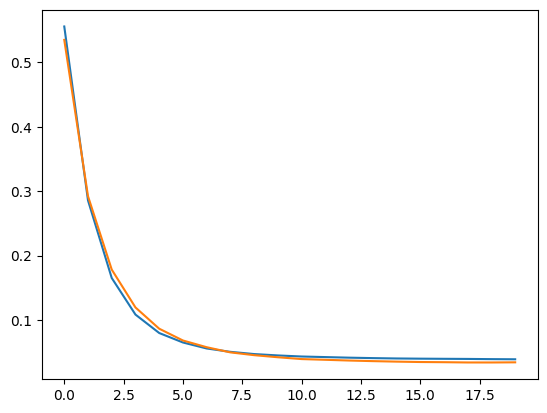

In [4]:
history = model.fit(x, t, epochs=20, batch_size=8, validation_split=0.1)

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(np.arange(len(loss)), loss)
plt.plot(np.arange(len(val_loss)), val_loss)
plt.show()

pred : [0.00194863 0.21079218 0.57366226 0.6343844  0.68420567 0.89010742
 1.06098721 0.80942305 0.73523318 0.87692963]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━

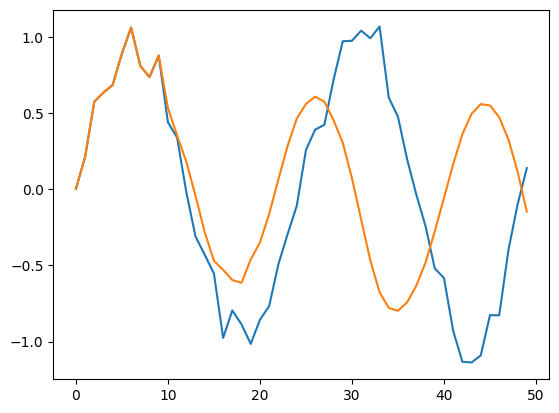

In [5]:
# 예측
pred = x[0].reshape(-1)
print('pred :', pred)

# 총 n_sample 횟수만큼 반복
for i in range(0, n_sample):
  yhat = model.predict(pred[-n_rnn:].reshape(1, n_rnn, 1))
  pred = np.append(pred, yhat[0][n_rnn - 1][0]) # 출력의 최후 결과 추가

plt.plot(np.arange(len(sindata)), sindata, label='Train data')
plt.plot(np.arange(len(pred)), pred, label='Pred data')
plt.show()

In [8]:
# 예측값과 실제값 비교
predicted = pred[n_rnn:]
actual = sindata[n_rnn:]

for i in range(10):
  print(f'{i:02d} - 예측:{predicted[i]:.4f}, 실제:{actual[i]:.4f}')

# MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(actual, predicted)
print(f'MSE : {mse:.5f}')

00 - 예측:0.5330, 실제:0.4392
01 - 예측:0.3520, 실제:0.3384
02 - 예측:0.1799, 실제:-0.0201
03 - 예측:-0.0441, 실제:-0.3109
04 - 예측:-0.2822, 실제:-0.4302
05 - 예측:-0.4702, 실제:-0.5537
06 - 예측:-0.5295, 실제:-0.9761
07 - 예측:-0.5965, 실제:-0.7957
08 - 예측:-0.6149, 실제:-0.8875
09 - 예측:-0.4609, 실제:-1.0153
MSE : 0.71912
